In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from datetime import datetime, timedelta
import random

random.seed(42)
np.random.seed(42)
SCRIPTS = Path('..') / 'ejemplos_codigo'
print('[OK] Entorno B12 listo')

[OK] Entorno B12 listo


In [2]:
# Crear directorio de exportacion de imagenes
import os
os.makedirs('images', exist_ok=True)
print('[OK] Directorio images/ listo')

[OK] Directorio images/ listo


# IA Aplicada al Negocio y Casos de Uso

Este bloque traduce los conceptos técnicos de los bloques anteriores  
a soluciones concretas para el negocio de la empresa.

**Principio fundamental:**
```
VARIABLE OBJETIVO primero  -->  TÉCNICA despues
```

Elegir el modelo antes de definir la variable objetivo es el error mas frecuente  
en proyectos de IA que fracasan en producción.

**Los 5 tipos de variable en los casos de este bloque:**

| Caso | Variable objetivo | Tipo |
|---|---|---|
| 12.1 Inventarios | Unidades de demanda en N dias | Regresión |
| 12.2 Sentimiento | Sentimiento + urgencia del mensaje | Clasificación multiple |
| 12.3 Churn | P(cancelación en 90 dias) | Probabilidad continua |
| 12.4 RFP | Estructura semántica del documento | Extracción |
| 12.5 Copiloto PO | User Story con criterios de aceptación | Generación |

**El tipo de variable determina la arquitectura. No al reves.**

> **Antes de seguir:** si tuvieras que elegir un solo proceso de la empresa o de la empresa para mejorar con IA este trimestre, ¿cuál sería y cómo formularías la variable objetivo en una frase?

<details>
<summary>Orientación para el instructor (desplegar tras la reflexión)</summary>

**Una respuesta madura menciona al menos uno de estos elementos:**
- Un proceso concreto, no una categoría general ("mejorar el soporte" no cuenta; "reducir el tiempo de triaje de tickets en el primer nivel" sí)
- Una variable objetivo formulada como número estimable: probabilidad de X en Y días, cantidad de Z, categoría entre {A, B, C}
- Una justificación del porqué ese proceso y no otro: impacto, datos disponibles, urgencia

**Si nadie responde, preguntar:**
"De todos los procesos de la empresa que conocéis, ¿cuál es el que más tiempo manual consume por semana? ¿Ese tiempo es predecible o variable?"

**Señal de comprensión:**
El alumno puede formular la variable objetivo en una frase específica. Si la formulación es vaga ("mejorar la eficiencia"), pedirle que la haga más concreta: "¿eficiencia medida cómo? ¿en qué unidades? ¿con qué horizonte?" La capacidad de responder a esas preguntas es la competencia central de este bloque.

</details>

## 12.1 Predicción Inteligente de Inventarios

**Problema**: las reglas estáticas de reposición (punto de pedido fijo, formulas clasicas)  
no capturan patrones no lineales: estacionalidad variable, correlaciones entre productos,  
efectos de promociones, disrupciones en la cadena de suministro.

**Variable objetivo**: unidades de demanda por SKU en los próximos N dias.  
No el stock optimo (eso es una regla sobre la estimación).  
No la orden de compra (eso es la acción consecuente).  
Es específicamente la magnitud que las formulas deterministas no pueden calcular.

**Decisión**: gradient boosting (XGBoost/LightGBM), no LLM.  
El conocimiento relevante esta en los patrones numéricos históricos, no en lenguaje.  
Mayor precisión que red neuronal para datos tabulares, y más interpretable.

**Diferenciación de la empresa**: de sistema que reacciona al stock bajo  
a sistema que anticipa la necesidad antes de que ocurra.

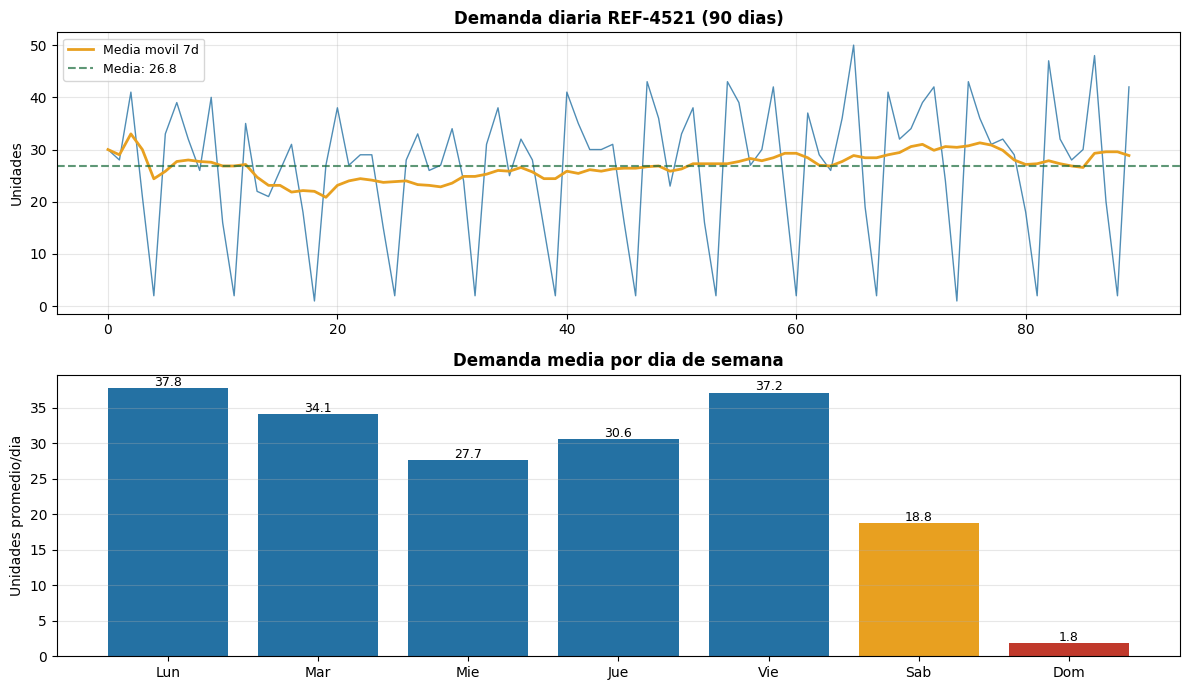


Features del modelo de inventarios:
 - ventas_7d: media movil de ventas ultimos 7 dias
 - ventas_30d: media movil de ventas ultimos 30 dias
 - dia_semana: codificado (0=lun ... 6=dom)
 - mes: 1-12
 - es_festivo: binario
 - precio_actual: normalizado
 - stock_actual: unidades disponibles
 - lead_time_proveedor: dias habituales de reposicion

Target: demanda en los proximos 7 dias (tipo: regresion)
Modelo recomendado: XGBoost / LightGBM (datos tabulares)
[X] No LLM: el conocimiento esta en patrones numericos, no en lenguaje


In [3]:
# Simulacion de features para un modelo de prediccion de inventarios
# Muestra como se estructura el dataset de entrenamiento

def generar_dataset_inventario(n_dias: int = 180, sku: str = 'REF-4521') -> list:
    """Genera datos de ventas simulados con estacionalidad y tendencia."""
    datos = []
    demanda_base = 25  # unidades/dia

    for i in range(n_dias):
        fecha = datetime(2025, 1, 1) + timedelta(days=i)
        dia_semana = fecha.weekday()  # 0=lunes, 6=domingo
        mes = fecha.month

        # Componentes de la demanda
        factor_semana = [1.2, 1.1, 1.0, 1.0, 1.3, 0.6, 0.4][dia_semana]
        factor_mes = 1.0 + 0.3 * np.sin(2 * np.pi * mes / 12)  # estacionalidad
        ruido = np.random.normal(1.0, 0.15)
        es_festivo = (dia_semana == 6) or (mes == 12 and fecha.day > 20)
        factor_festivo = 0.2 if es_festivo else 1.0

        demanda = max(0, int(demanda_base * factor_semana * factor_mes * ruido * factor_festivo))

        datos.append({
            'fecha': fecha.strftime('%Y-%m-%d'),
            'sku': sku,
            'dia_semana': dia_semana,
            'mes': mes,
            'es_festivo': int(es_festivo),
            'demanda': demanda,
        })

    return datos


# Generar y analizar
dataset = generar_dataset_inventario(n_dias=90)
demandas = [d['demanda'] for d in dataset]
fechas = [d['fecha'] for d in dataset]

# Visualizacion
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Serie temporal de demanda
axes[0].plot(range(len(demandas)), demandas, color='#2471a3', linewidth=1, alpha=0.8)
media_movil = [np.mean(demandas[max(0,i-6):i+1]) for i in range(len(demandas))]
axes[0].plot(range(len(media_movil)), media_movil, color='#e8a020', linewidth=2, label='Media movil 7d')
axes[0].axhline(np.mean(demandas), color='#1a6b3c', linestyle='--', alpha=0.7, label=f'Media: {np.mean(demandas):.1f}')
axes[0].set_title('Demanda diaria REF-4521 (90 dias)', fontweight='bold')
axes[0].set_ylabel('Unidades')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Patron por dia de semana
dias = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
demanda_por_dia = [np.mean([d['demanda'] for d in dataset if d['dia_semana'] == i]) for i in range(7)]
colores = ['#2471a3']*5 + ['#e8a020', '#c0392b']
axes[1].bar(dias, demanda_por_dia, color=colores)
axes[1].set_title('Demanda media por dia de semana', fontweight='bold')
axes[1].set_ylabel('Unidades promedio/dia')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(demanda_por_dia):
    axes[1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/B12_fig01.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')


print('\nFeatures del modelo de inventarios:')
features = [
    'ventas_7d: media movil de ventas ultimos 7 dias',
    'ventas_30d: media movil de ventas ultimos 30 dias',
    'dia_semana: codificado (0=lun ... 6=dom)',
    'mes: 1-12',
    'es_festivo: binario',
    'precio_actual: normalizado',
    'stock_actual: unidades disponibles',
    'lead_time_proveedor: dias habituales de reposicion',
]
for f in features:
    print(f' - {f}')

print(f'\nTarget: demanda en los proximos 7 dias (tipo: regresion)')
print(f'Modelo recomendado: XGBoost / LightGBM (datos tabulares)')
print(f'[X] No LLM: el conocimiento esta en patrones numericos, no en lenguaje')

## 12.3 Predicción de Churn

**Variable objetivo**: P(cancelación en los próximos 90 dias).  
No una categoria ('en riesgo / seguro'), sino un **número continuo entre 0 y 1**  
que permite ordenar todos los clientes por urgencia de intervención.

**El horizonte temporal N no es un detalle técnico.**  
Un modelo de churn a 30 dias y uno a 180 dias son modelos distintos.  
Decidir el horizonte antes de construir el modelo es parte de la formulación del problema.

**Decisión**: gradient boosting, no LLM.  
El conocimiento esta en patrones de comportamiento numerico.  
La salida necesita ser explicable (SHAP values), no una justificación generada.

In [4]:
# Simulacion de scoring de churn con SHAP values explicativos

# Features de comportamiento de un cliente
CLIENTES = [
    {
        'nombre': 'Distribuciones Lopez S.L.',
        'logins_semana': 18,   # alto uso
        'tickets_mes': 2,
        'tendencia_uso': +0.1,  # creciente
        'pagos_puntuales': 0.98,
        'nps_ultimo': 8,
        'meses_sin_nuevas_funciones': 0,
    },
    {
        'nombre': 'Comercial Ruiz e Hijos',
        'logins_semana': 4,    # bajo uso
        'tickets_mes': 8,      # muchos tickets
        'tendencia_uso': -0.35,  # decreciente
        'pagos_puntuales': 0.72,  # problemas de pago
        'nps_ultimo': 4,
        'meses_sin_nuevas_funciones': 5,
    },
    {
        'nombre': 'Electronica Morales',
        'logins_semana': 9,
        'tickets_mes': 5,
        'tendencia_uso': -0.1,
        'pagos_puntuales': 0.91,
        'nps_ultimo': 6,
        'meses_sin_nuevas_funciones': 2,
    },
]

def calcular_riesgo_churn(cliente: dict) -> tuple:
    """
    Modelo de scoring de churn simplificado.
    En produccion seria un gradient boosting entrenado con datos historicos.
    Retorna (probabilidad, shap_values).
    """
    # Pesos por feature (equivalente a SHAP values agregados)
    contribuciones = {}
    score = 0.15  # base

    # Logins (bajo uso = mayor riesgo)
    contribucion_logins = max(0, (10 - cliente['logins_semana']) / 10) * 0.20
    contribuciones['bajo_uso'] = round(contribucion_logins, 3)
    score += contribucion_logins

    # Tendencia de uso (decreciente = alto riesgo)
    contribucion_tendencia = max(0, -cliente['tendencia_uso']) * 0.35
    contribuciones['tendencia_decreciente'] = round(contribucion_tendencia, 3)
    score += contribucion_tendencia

    # Pagos
    contribucion_pagos = (1 - cliente['pagos_puntuales']) * 0.20
    contribuciones['problemas_pago'] = round(contribucion_pagos, 3)
    score += contribucion_pagos

    # NPS
    contribucion_nps = max(0, (6 - cliente['nps_ultimo']) / 6) * 0.15
    contribuciones['nps_bajo'] = round(contribucion_nps, 3)
    score += contribucion_nps

    # Tickets
    contribucion_tickets = min(0.10, cliente['tickets_mes'] / 100)
    contribuciones['alto_soporte'] = round(contribucion_tickets, 3)
    score += contribucion_tickets

    # Normalizar a [0, 1]
    prob = min(0.99, max(0.01, score))
    return prob, contribuciones


print('=== Scoring de Churn - Clientes la empresa ===')
print()

resultados = []
for cliente in CLIENTES:
    prob, shap = calcular_riesgo_churn(cliente)
    resultados.append((cliente['nombre'], prob, shap))

# Ordenar por probabilidad descendente
resultados.sort(key=lambda x: x[1], reverse=True)

for nombre, prob, shap in resultados:
    nivel = 'CRITICO' if prob > 0.5 else 'MEDIO' if prob > 0.25 else 'BAJO'
    marcador = '[!!!]' if nivel == 'CRITICO' else '[! ]' if nivel == 'MEDIO' else '[OK]'
    print(f'{marcador} {nombre}')
    print(f'       P(churn 90d): {prob:.1%}  [{nivel}]')
    # Top 2 factores de riesgo
    factores_top = sorted(shap.items(), key=lambda x: x[1], reverse=True)[:2]
    for factor, contribucion in factores_top:
        if contribucion > 0:
            print(f'       Factor: {factor} (contribucion: +{contribucion:.3f})')
    print()

print('Accion recomendada para clientes CRITICO: contacto proactivo de Customer Success')
print('Accion recomendada para clientes MEDIO: review mensual automatico')
print('Accion recomendada para clientes BAJO: campana automatizada de engagement')

=== Scoring de Churn -  Clientes la empresa ===

[!!!] Comercial Ruiz e Hijos
       P(churn 90d): 57.9%  [CRITICO]
       Factor: tendencia_decreciente (contribucion: +0.122)
       Factor: bajo_uso (contribucion: +0.120)

[! ] Electronica Morales
       P(churn 90d): 27.3%  [MEDIO]
       Factor: alto_soporte (contribucion: +0.050)
       Factor: tendencia_decreciente (contribucion: +0.035)

[OK] Distribuciones Lopez S.L.
       P(churn 90d): 17.4%  [BAJO]
       Factor: alto_soporte (contribucion: +0.020)
       Factor: problemas_pago (contribucion: +0.004)

Accion recomendada para clientes CRITICO: contacto proactivo de Customer Success
Accion recomendada para clientes MEDIO: review mensual automatico
Accion recomendada para clientes BAJO: campana automatizada de engagement


## 12.4 Procesamiento Inteligente de RFPs

**Variable objetivo**: la estructura semántica del documento.  
Para cada fragmento: categoría (técnico/funcional/legal/comercial)  
y obligatoriedad (obligatorio/deseable/informativo).

No es una predicción sobre el futuro.  
Es una **extracción de propiedades presentes en texto no estructurado**  
que un sistema de reglas no puede leer porque el lenguaje natural no tiene estructura fija.

**Arquitectura**: pipeline RAG en 3 fases:
```
RFP (PDF)  -->  [Extracción de requisitos]  -->  lista estructurada
                        |
             [Matching con capacidades la empresa via RAG]
                        |
             [Generación del borrador de respuesta]
```

**Impacto**: de dias a horas por RFP.  
Capacidad de responder a mas RFPs simultáneamente sin aumentar el equipo.

In [5]:
# Pipeline de procesamiento de RFP: extraccion y matching

# Fragmento de RFP simulado
FRAGMENTO_RFP = """
3.1 REQUISITOS TECNICOS OBLIGATORIOS
El sistema debe disponer de un modulo de gestion de inventarios en tiempo real
que permita la consulta de stock desde cualquier dispositivo. Es obligatorio
que el sistema soporte integracion via API REST con el ERP existente SAP B1.
El tiempo de respuesta de las consultas de stock no debera superar los 2 segundos.

3.2 REQUISITOS FUNCIONALES DESEABLES
Se valora positivamente que el sistema incluya capacidades de prediccion
de demanda basadas en inteligencia artificial. Asimismo, se valora la
disponibilidad de un dashboard de analitica avanzada para el equipo directivo.

3.3 CONDICIONES LEGALES
El proveedor debera cumplir con el Reglamento General de Proteccion de Datos
(RGPD). Todos los datos deberan almacenarse en servidores ubicados en territorio
de la Union Europea.
"""

# Capacidades de la empresa (base de conocimiento)
CAPACIDADES_EMPRESA = {
    'inventario_tiempo_real': {
        'disponible': True,
        'descripcion': 'Modulo de inventarios con actualizacion en tiempo real y acceso web',
    },
    'api_rest': {
        'disponible': True,
        'descripcion': 'API REST documentada con OpenAPI 3.0, soporte OAuth2',
    },
    'integracion_sap': {
        'disponible': True,
        'descripcion': 'Conector nativo certificado para SAP Business One',
    },
    'rendimiento_2s': {
        'disponible': True,
        'descripcion': 'SLA de latencia P95 < 1.5s en consultas de stock',
    },
    'prediccion_demanda_ia': {
        'disponible': True,
        'descripcion': 'Modulo de prediccion de inventarios con ML (roadmap Q3 2025)',
    },
    'dashboard_directivo': {
        'disponible': True,
        'descripcion': 'Dashboard ejecutivo con KPIs configurables y exportacion a Power BI',
    },
    'rgpd_compliant': {
        'disponible': True,
        'descripcion': 'Certificacion ENS, DPA disponible, auditoria anual por tercero',
    },
    'datos_ue': {
        'disponible': True,
        'descripcion': 'Infraestructura en Azure West Europe (Amsterdam) y Spain Central (Madrid)',
    },
}

def extraer_requisitos_rfp(fragmento: str) -> list:
    """
    Extraccion de requisitos (simulada - en produccion: llamada al LLM).
    """
    # En produccion esto seria una llamada al LLM con el prompt de extraccion
    return [
        {'id': 'REQ-001', 'texto': 'Modulo de inventarios en tiempo real accesible desde cualquier dispositivo',
         'categoria': 'tecnico', 'obligatoriedad': 'obligatorio', 'capacidad_key': 'inventario_tiempo_real'},
        {'id': 'REQ-002', 'texto': 'Integracion via API REST con SAP Business One',
         'categoria': 'tecnico', 'obligatoriedad': 'obligatorio', 'capacidad_key': 'integracion_sap'},
        {'id': 'REQ-003', 'texto': 'Tiempo de respuesta de consultas de stock < 2 segundos',
         'categoria': 'tecnico', 'obligatoriedad': 'obligatorio', 'capacidad_key': 'rendimiento_2s'},
        {'id': 'REQ-004', 'texto': 'Prediccion de demanda con inteligencia artificial',
         'categoria': 'funcional', 'obligatoriedad': 'deseable', 'capacidad_key': 'prediccion_demanda_ia'},
        {'id': 'REQ-005', 'texto': 'Dashboard de analitica avanzada para equipo directivo',
         'categoria': 'funcional', 'obligatoriedad': 'deseable', 'capacidad_key': 'dashboard_directivo'},
        {'id': 'REQ-006', 'texto': 'Cumplimiento RGPD',
         'categoria': 'legal', 'obligatoriedad': 'obligatorio', 'capacidad_key': 'rgpd_compliant'},
        {'id': 'REQ-007', 'texto': 'Datos almacenados en servidores en la Union Europea',
         'categoria': 'legal', 'obligatoriedad': 'obligatorio', 'capacidad_key': 'datos_ue'},
    ]


def analizar_cobertura(requisitos: list, capacidades: dict) -> list:
    """Mapea requisitos contra capacidades de la empresa."""
    resultados = []
    for req in requisitos:
        cap = capacidades.get(req['capacidad_key'], {})
        if cap.get('disponible'):
            estado = 'CUBIERTO'
        else:
            estado = 'GAP'
        resultados.append({
            **req,
            'cobertura': estado,
            'respuesta': cap.get('descripcion', 'Funcionalidad no disponible'),
        })
    return resultados


requisitos = extraer_requisitos_rfp(FRAGMENTO_RFP)
analisis = analizar_cobertura(requisitos, CAPACIDADES_EMPRESA)

print('=== Analisis de Cobertura RFP vs la empresa ===')
print()
obligatorios_cubiertos = sum(1 for r in analisis if r['obligatoriedad'] == 'obligatorio' and r['cobertura'] == 'CUBIERTO')
obligatorios_total = sum(1 for r in analisis if r['obligatoriedad'] == 'obligatorio')

for r in analisis:
    icono = '[OK]' if r['cobertura'] == 'CUBIERTO' else '[X] '
    prioridad = '[OBL]' if r['obligatoriedad'] == 'obligatorio' else '[DES]'
    print(f'{icono} {r["id"]} {prioridad} [{r["categoria"]}] {r["texto"][:55]}')
    print(f'       {r["respuesta"][:70]}')
    print()

print(f'Resumen: {obligatorios_cubiertos}/{obligatorios_total} requisitos obligatorios cubiertos')
print(f'Cobertura total: {len([r for r in analisis if r["cobertura"]=="CUBIERTO"])}/{len(analisis)} requisitos')

=== Analisis de Cobertura RFP vs la empresa ===

[OK] REQ-001 [OBL] [tecnico] Modulo de inventarios en tiempo real accesible desde cu
       Modulo de inventarios con actualizacion en tiempo real y acceso web

[OK] REQ-002 [OBL] [tecnico] Integracion via API REST con SAP Business One
       Conector nativo certificado para SAP Business One

[OK] REQ-003 [OBL] [tecnico] Tiempo de respuesta de consultas de stock < 2 segundos
       SLA de latencia P95 < 1.5s en consultas de stock

[OK] REQ-004 [DES] [funcional] Prediccion de demanda con inteligencia artificial
       Modulo de prediccion de inventarios con ML (roadmap Q3 2025)

[OK] REQ-005 [DES] [funcional] Dashboard de analitica avanzada para equipo directivo
       Dashboard ejecutivo con KPIs configurables y exportacion a Power BI

[OK] REQ-006 [OBL] [legal] Cumplimiento RGPD
       Certificacion ENS, DPA disponible, auditoria anual por tercero

[OK] REQ-007 [OBL] [legal] Datos almacenados en servidores en la Union Europea
       Inf

## 12.8 Text-to-SQL: Acceso a Datos en Lenguaje Natural

La barrera mas comun en el acceso a datos no es la tecnologia, sino el lenguaje.  
Un responsable de negocio sabe que pregunta quiere responder,  
pero no sabe escribir la consulta SQL necesaria.

**Guardrails críticos para text-to-SQL:**
- Nunca ejecutar consultas generadas directamente en producción sin validación
- Limitar operaciones a SELECT (nunca UPDATE, DELETE, DROP)
- Usar usuario de BD con permisos de solo lectura
- Validar que la consulta referencia solo tablas y columnas existentes
- Limitar tiempo de ejecución para evitar consultas que bloqueen la BD

In [6]:
# Validador de SQL generado por LLM
# Asegura que el SQL generado es seguro antes de ejecutarlo

import re

SCHEMA_EMPRESA = {
    'products':    ['id', 'name', 'sku', 'category_id', 'price', 'created_at'],
    'orders':      ['id', 'customer_id', 'order_date', 'status', 'total_amount'],
    'order_lines': ['id', 'order_id', 'product_id', 'quantity', 'unit_price'],
    'customers':   ['id', 'name', 'region', 'segment', 'created_at'],
    'warehouses':  ['id', 'name', 'location', 'capacity'],
    'inventory':   ['product_id', 'warehouse_id', 'quantity', 'last_updated'],
}

def validar_sql_generado(sql: str, schema: dict) -> tuple:
    """
    Valida el SQL generado por el LLM antes de ejecutarlo.
    Retorna (es_valido, lista_problemas).
    """
    sql_upper = sql.upper().strip()
    problemas = []

    # 1. Solo SELECT permitido
    operaciones_prohibidas = ['INSERT', 'UPDATE', 'DELETE', 'DROP', 'TRUNCATE', 'ALTER', 'CREATE']
    for op in operaciones_prohibidas:
        if re.search(r'\b' + op + r'\b', sql_upper):
            problemas.append(f'Operacion prohibida detectada: {op}')

    if not sql_upper.lstrip().startswith('SELECT'):
        problemas.append('La consulta no empieza con SELECT')

    # 2. Solo tablas del schema
    tablas_en_sql = re.findall(r'(?:FROM|JOIN)\s+(\w+)', sql_upper)
    for tabla in tablas_en_sql:
        if tabla.lower() not in schema:
            problemas.append(f'Tabla no existe en el schema: {tabla}')

    # 3. Sin comentarios maliciosos
    if '--' in sql or '/*' in sql:
        problemas.append('Comentarios SQL detectados (posible inyeccion)')

    return len(problemas) == 0, problemas


# Casos de prueba: consultas generadas por el LLM
consultas_test = [
    (
        "SELECT p.name, p.sku, SUM(ol.quantity) as total FROM order_lines ol JOIN products p ON ol.product_id = p.id GROUP BY p.name, p.sku ORDER BY total DESC LIMIT 10",
        'Consulta valida: top 10 productos mas vendidos',
    ),
    (
        "SELECT * FROM customers; DELETE FROM orders WHERE id > 0",
        'Inyeccion: DELETE despues de SELECT',
    ),
    (
        "SELECT * FROM credit_cards WHERE cvv IS NOT NULL",
        'Tabla que no existe en el schema',
    ),
    (
        "UPDATE products SET price = 0 WHERE 1=1",
        'Operacion prohibida: UPDATE',
    ),
    (
        "SELECT c.name, COUNT(o.id) as pedidos, SUM(o.total_amount) as total FROM customers c JOIN orders o ON c.id = o.customer_id WHERE o.order_date >= '2025-01-01' GROUP BY c.name ORDER BY total DESC",
        'Consulta valida: clientes con mas ventas en 2025',
    ),
]

print('=== Validacion de SQL generado por LLM ===')
print()
for sql, descripcion in consultas_test:
    valido, problemas = validar_sql_generado(sql, SCHEMA_EMPRESA)
    estado = '[OK]' if valido else '[X] '
    print(f'{estado} {descripcion}')
    if not valido:
        for p in problemas:
            print(f'       Problema: {p}')
    print()

=== Validacion de SQL generado por LLM ===

[OK] Consulta valida: top 10 productos mas vendidos

[X]  Inyeccion: DELETE despues de SELECT
       Problema: Operacion prohibida detectada: DELETE

[X]  Tabla que no existe en el schema
       Problema: Tabla no existe en el schema: CREDIT_CARDS

[X]  Operacion prohibida: UPDATE
       Problema: Operacion prohibida detectada: UPDATE
       Problema: La consulta no empieza con SELECT

[OK] Consulta valida: clientes con mas ventas en 2025



---
## 7. Ejercicio de Decisión: ¿usarias IA aquí?

### Caso: elegir entre dos proyectos de IA con presupuesto limitado

la empresa tiene presupuesto para un proyecto de IA este trimestre. Dos candidatos:

**Proyecto A** - Clasificador de tickets de soporte
Valor estimado: 2 horas/dia de ahorro en triaje manual.
Datos: disponibles, bien etiquetados, 3.000 tickets históricos.
Complejidad técnica: baja.

**Proyecto B** - Predictor de renovación de contratos
Valor estimado: detectar a tiempo el 15% de clientes que no renuevan.
Datos: disponibles en el ERP, pero no etiquetados (hay que construir el dataset).
Complejidad técnica: media.

---

**Pregunta 1 - El valor económico**
¿Como calcularias el valor económico de cada proyecto para compararlos?
Usa números aunque sean estimaciones.

**Pregunta 2 - El impacto de los datos**
El proyecto A tiene datos listos y el B requiere trabajo previo de etiquetado.
¿Cambia eso tu decisión? ¿Como ponderarias dificultad técnica vs valor de negocio?

**Pregunta 3 - Las preguntas al equipo de negocio**
Antes de decidir, ¿que preguntarias al equipo comercial? Lista al menos 3 preguntas
cuya respuesta podria cambiar completamente tu elección.

**Pregunta 4 - El proyecto C**
¿Existe un tercer proyecto que no esta en la lista pero podria tener mas valor que ambos?
Propone uno y justifica por que.

---
*Escribe tus respuestas en la celda siguiente.*

### Mis respuestas

**Pregunta 1 - El valor económico:**

*(escribe aquí)*

**Pregunta 2 - El impacto de los datos:**

*(escribe aquí)*

**Pregunta 3 - Las preguntas al equipo de negocio:**

*(escribe aquí)*

**Pregunta 4 - El proyecto C:**

*(escribe aquí)*

---

<!--
CRITERIOS DE Evaluación (para el instructor)

Pregunta 1 - El valor económico:
Proyecto A: 2h/dia * 5 dias/semana * 50 semanas = 500h/ano. A 30 EUR/h = 15.000 EUR/ano.
Proyecto B: 15% de los clientes que no renuevan detectados a tiempo.
Si la empresa tiene 200 clientes y renueva el 85%, hay 30 cancelaciones al ano.
15% de 30 = 4,5 clientes recuperados. Si cada contrato vale 10.000 EUR = 45.000 EUR/ano.
El alumno no necesita usar exactamente estos números, pero si mostrar el método de cálculo.
Insuficiente: "el proyecto B tiene mas valor" sin cuantificar.

Pregunta 2 - El impacto de los datos:
Respuesta madura: el esfuerzo de etiquetado del proyecto B es un coste adicional,
pero la pregunta clave es si ese coste es recuperable con el valor que genera.
Si el proyecto B vale 3x mas, el coste de etiquetado puede estar justificado.
Lo que cambia la decisión: si el equipo comercial puede etiquetar los datos
en paralelo a su trabajo diario sin coste extra, el balance se inclina hacia B.
Insuficiente: "elegiria A porque tiene datos listos" sin evaluar el coste-beneficio.

Pregunta 3 - Las preguntas al equipo de negocio:
Preguntas que cambian la decisión:
 - Cuantos contratos se pierden al ano y cual es el valor medio de un contrato? (cuantifica B)
 - Cuanto tiempo dedica el equipo al triaje de tickets actualmente? (cuantifica A)
 - Con cuanta antelacion se detecta hoy que un cliente no va a renovar? (urgencia de B)
 - Hay alguien en el equipo comercial que pueda etiquetar datos de renovacion durante 2-4 semanas? (viabilidad de B)
 - Que pasa si el clasificador de tickets se equivoca: quien resuelve el error? (coste del error de A)
Insuficiente: preguntar solo por el presupuesto disponible o por preferencias tecnologicas.

Pregunta 4 - El proyecto C:
Cualquier proyecto valido que:
 - Tenga datos disponibles o facilmente obtenibles
 - Tenga valor económico mayor o comparable
 - Sea tecnicamente mas sencillo que B
Ejemplo valido: automatizar la generación de informes mensuales de cliente (ahorro de tiempo, datos estructurados en el ERP, bajo riesgo).
Otro ejemplo: clasificador de emails entrantes para priorizar oportunidades (datos disponibles, valor comercial directo).
Penalizar: proyectos sin datos disponibles o con valor puramente estetico.
-->


## Resumen del Bloque 12

**La pregunta que siempre viene primero:**
```
Que necesitamos que el sistema produzca?
     |-- un número continuo    -->  regresión (inventarios, churn)
     |-- una categoria         -->  clasificación (sentimiento, tickets)
     |-- una estructura JSON   -->  extracción (RFP, emails)
     +-- un texto largo        -->  generación (User Story, propuesta)
```

**Guia de selección de técnica:**

| Variable objetivo | Datos de entrada | Técnica |
|---|---|---|
| Magnitud futura continua | Series temporales + tabulares | Gradient boosting (XGBoost/LightGBM) |
| Probabilidad de evento | Features de comportamiento | Clasificación supervisada + SHAP |
| Propiedades en texto | Texto no estructurado | LLM via API (Claude Haiku) |
| Artefacto complejo con contexto | Backlog + historial + docs | LLM via API + RAG |

**El argumento de ROI de la empresa:**  
La IA no reemplaza una tarea que alguien hacia:  
hace posible una tarea que nadie hacia porque era imposible a ese volumen.

**Siguiente bloque (B13):** El Desafio la empresa - 
proponer, diseñar e implementar un caso de uso real.